# Homework 1
### Joshua Dunne
### MATH675 Spring 2026 CSUEB

## Question 1
$$
\begin{align*}
\textbf{a. }\quad & \frac{dx}{dt} = -x\quad\frac{dy}{dt} = -5y 
& \textbf{b. }\quad & \frac{dx}{dt} = 4x - y\quad\frac{dy}{dt} = 2x + y 
\\ \textbf{c. }\quad & \frac{dx_1}{dt} = x_2\quad\frac{dx_2}{dt} = -2x_1-3x_2
& \textbf{d. }\quad & \frac{dx_1}{dt} = 5x+2y\quad\frac{dx_2}{dt} = -17x-5y
\end{align*}
$$

### Part i
We're being given a set of differential equations, a through d, and being asked to do several things with them. The first thing that's being asked is whether it is coupled or uncoupled. This would mean there was atleast one dependency on a variable from another equation in the system. So, for a $\frac{dx}{dt} = -x$ this has no dependency on y, and, likewise, for $\frac{dy}{dt} = -5y$ this has no dependency on x. Therefore, this system is uncoupled. We can go likewise through the rest.
<ol type="a">
    <li> Uncoupled </li>
    <li> Coupled </li>
    <li> Coupled </li>
    <li> Coupled </li>
</ol>

### Part ii
Now we want to plot a change vector on the state space at the points (1,1), (1,-1), (-1,-1), and (1,-1)

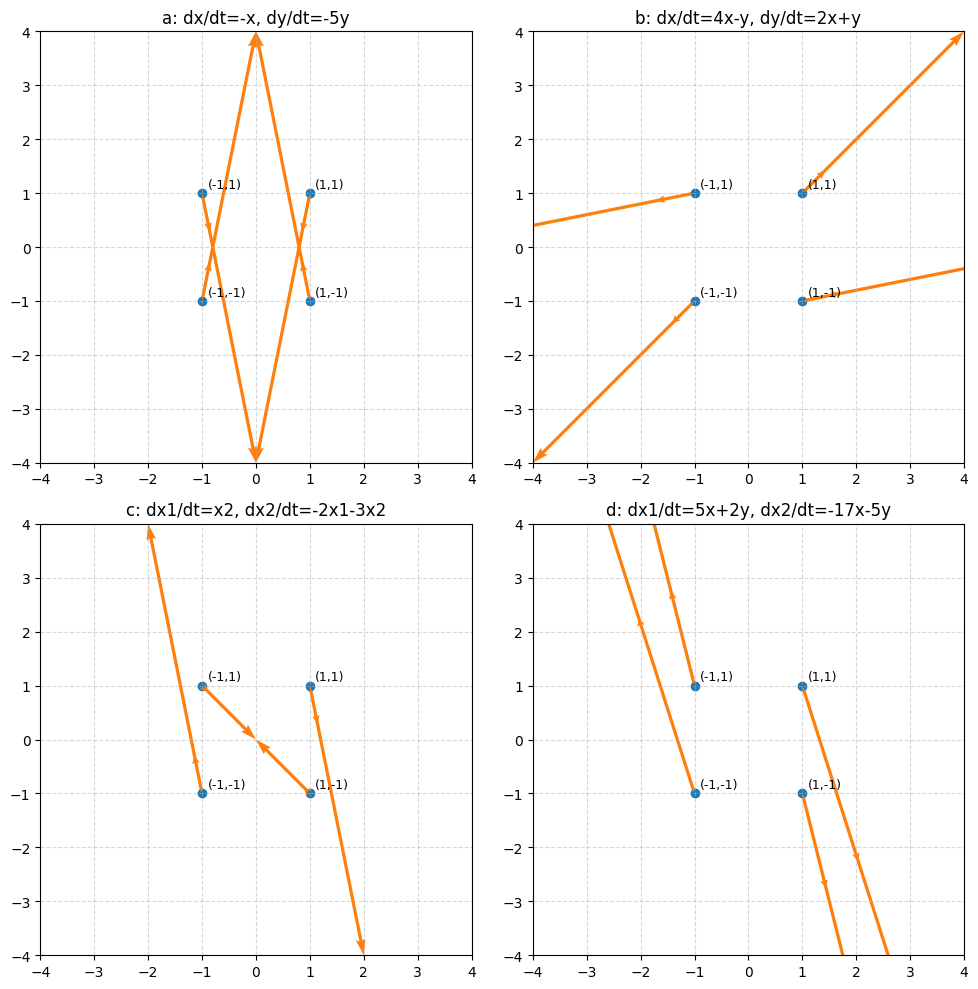

In [17]:
import numpy as np

import matplotlib.pyplot as plt

points = np.array([[1, 1], [1, -1], [-1, -1], [-1, 1]])

systems = {
    "a: dx/dt=-x, dy/dt=-5y": lambda x, y: (-x, -5 * y),
    "b: dx/dt=4x-y, dy/dt=2x+y": lambda x, y: (4 * x - y, 2 * x + y),
    "c: dx1/dt=x2, dx2/dt=-2x1-3x2": lambda x, y: (y, -2 * x - 3 * y),
    "d: dx1/dt=5x+2y, dx2/dt=-17x-5y": lambda x, y: (5 * x + 2 * y, -17 * x - 5 * y),
}

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for ax, (title, f) in zip(axes, systems.items()):
    X, Y = points[:, 0], points[:, 1]
    U, V = f(X, Y)
    ax.quiver(X, Y, U, V, angles="xy", scale_units="xy", scale=1, color="C1")
    ax.scatter(X, Y, color="C0")
    for (x, y, u, v) in zip(X, Y, U, V):
        ax.annotate("", xy=(x + u * 0.15, y + v * 0.15), xytext=(x, y),
                    arrowprops=dict(arrowstyle="->", color="C1"))
        ax.text(x + 0.1, y + 0.1, f"({x},{y})", fontsize=9)
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_aspect("equal")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.set_title(title)

plt.tight_layout()
plt.show()

What we're doing here is simple. We want, visually, the direction of change, for each system that is given, of the system, starting at the given points. Mathematically, this would look something like this for system b
$$
\begin{align*}
\text{At point }(1,1): & \left(\frac{dx}{dt}, \frac{dy}{dt}\right) = \left(4(1) - 1, 2(1) + 1\right) = (3, 3) \\
\text{At point }(1,-1): & \left(\frac{dx}{dt}, \frac{dy}{dt}\right) = \left(4(1) - (-1), 2(1) + (-1)\right) = (5, 1) \\
\text{At point }(-1,-1): & \left(\frac{dx}{dt}, \frac{dy}{dt}\right) = \left(4(-1) - (-1), 2(-1) + (-1)\right) = (-3, -3) \\
\text{At point }(-1,1): & \left(\frac{dx}{dt}, \frac{dy}{dt}\right) = \left(4(-1) - 1, 2(-1) + 1\right) = (-5, -1) \\
\end{align*}
$$

### Part iii
We want the equilibrium point for each system. This would be where there is no change in the system, so, we can simply equate againt 0 and solve the systems in each case. Since we'r still dealing with linear, these are just matrices.
$$
\begin{align*}
\textbf{ \quad a. } &
    \begin{array}{cc|c}
        -1 & 0 & 0 \\
        0 & -5 & 0
    \end{array}
    \Rightarrow (0,0)
\textbf{ \quad b. } &
    \begin{array}{cc|c}
        4 & -1 & 0 \\
        2 & 1 & 0
    \end{array}
    \Rightarrow (0,0)
\textbf{ \quad c. } &
    \begin{array}{cc|c}
        0 & 1 & 0 \\
        -2 & -3 & 0
    \end{array}
    \Rightarrow (0,0)
\textbf{ \quad d. } &
    \begin{array}{cc|c}
        5 & 2 & 0 \\
        -17 & -5 & 0
    \end{array}
    \Rightarrow (0,0)
\end{align*}
$$
So, the only solutions are trivial. And this is what we'd expect from linear systems with no constants.


### Part iiii and Part iv
Vector fields are next here. We can take the same scope as we were using above (-4, 4), and that should give us a half decent idea of where we're going

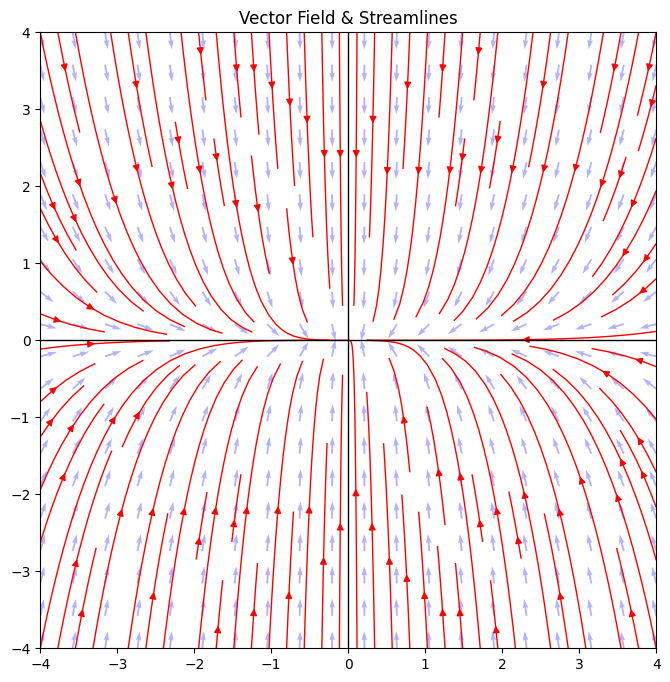

In [18]:
# Slower this time, I just banged it out the first time

# First, we can a set of points to work with, we need x and y, let's say 20 points between -4 and 4
x = np.linspace(-4, 4, 20)
y = np.linspace(-4, 4, 20)
# We want this as coordinate pairs to work with, so, meshgrid
X, Y = np.meshgrid(x, y)

#print(X)
#print(Y)

# The output here is what I was hoping for, so, continuing, let's set up
fOfA = lambda x, y : (-x, -5*y)
uOfA, vOfA = fOfA(X, Y)

# And normalize, I'll look up in numpy next time, I know there's an easier way
magOfA = np.sqrt(uOfA**2 + vOfA**2)
magOfA[magOfA == 0] = 1 
uOfANormalized = uOfA / magOfA
vOfANormalized = vOfA / magOfA

# The rest here is just adapted boilerplate from other classes to get the graphing done

import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 8))

ax.quiver(X, Y, uOfANormalized, vOfANormalized, color='blue', alpha=0.3)

ax.streamplot(X, Y, uOfA, vOfA, color='red', linewidth=1, density=1.2)

ax.axhline(0, color='black', lw=1) # X-axis
ax.axvline(0, color='black', lw=1) # Y-axis
ax.set_aspect('equal')
ax.set_title("Vector Field & Streamlines")
plt.show()

Alright, we have a nice way of doing it for one, so, let's come up with a nice way to do it for many at once, then I can use this later and only have to make a few changes

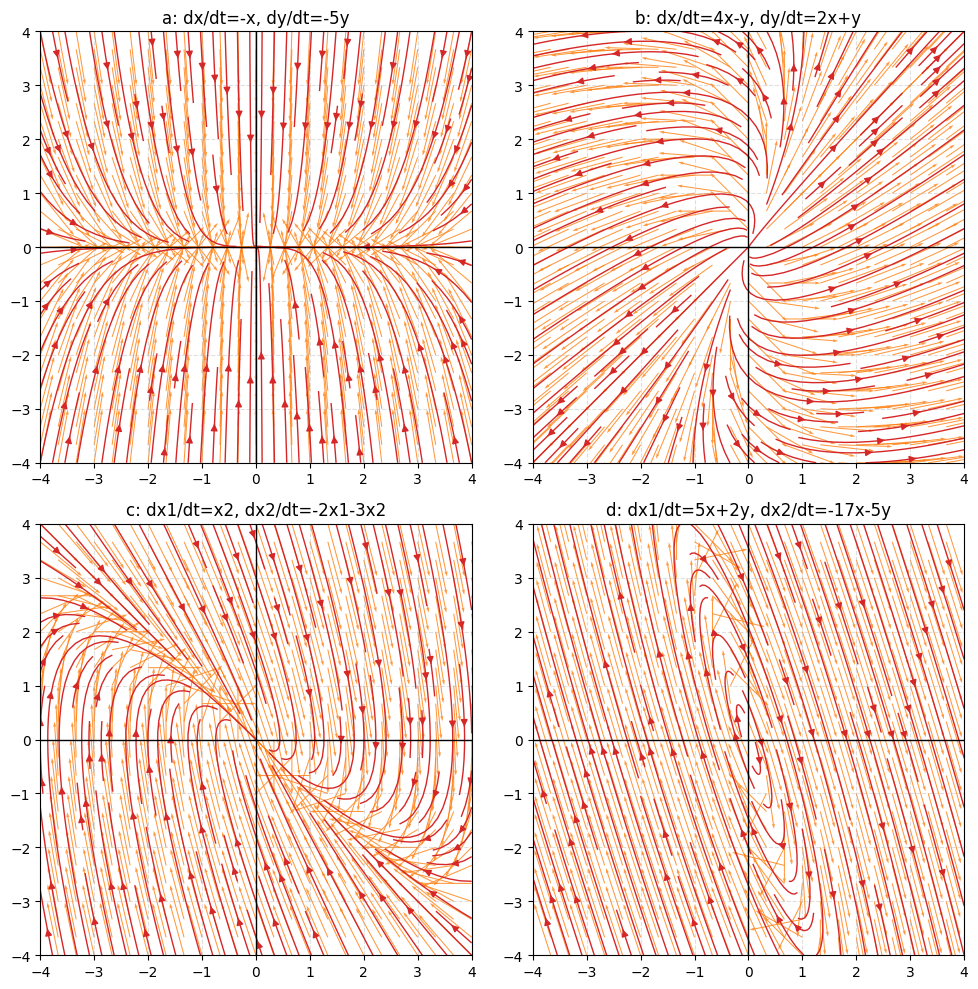

In [19]:
def plot_vector_field(f, ax=None, xlim=(-4, 4), ylim=(-4, 4), nx=20, ny=20,
                      normalize=True, stream=True, quiver_kwargs=None, stream_kwargs=None,
                      title=None):
    """
    f: callable f(X, Y) -> (U, V) (supports numpy arrays)
    ax: matplotlib Axes or None
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    else:
        fig = ax.figure

    x = np.linspace(xlim[0], xlim[1], nx)
    y = np.linspace(ylim[0], ylim[1], ny)
    X, Y = np.meshgrid(x, y)
    U, V = f(X, Y)

    # quiver kwargs
    qk = {"angles": "xy", "scale_units": "xy", "scale": 1, "color": "C1", "alpha": 0.8}
    if quiver_kwargs:
        qk.update(quiver_kwargs)

    if normalize:
        M = np.sqrt(U**2 + V**2)
        M[M == 0] = 1.0
        Un = U / M
        Vn = V / M
        ax.quiver(X, Y, Un, Vn, **qk)
    else:
        ax.quiver(X, Y, U, V, **qk)

    if stream:
        sk = {"color": "tab:red", "linewidth": 1, "density": 1.2}
        if stream_kwargs:
            sk.update(stream_kwargs)
        ax.streamplot(X, Y, U, V, **sk)

    ax.axhline(0, color="k", lw=1)
    ax.axvline(0, color="k", lw=1)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal")
    ax.grid(True, linestyle="--", alpha=0.4)
    if title:
        ax.set_title(title)
    return fig, ax

def plot_systems_grid(systems, ncols=2, xlim=(-4,4), ylim=(-4,4), nx=20, ny=20,
                      normalize=True, stream=True, figsize=(10, 10), quiver_kwargs=None, stream_kwargs=None):
    """
    systems: iterable of (f, title) or dict-like items
    returns (fig, axes) where axes is a flattened array
    """
    items = list(systems.items()) if isinstance(systems, dict) else list(systems)
    n = len(items)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).reshape(-1)
    for ax, (title, f) in zip(axes, items) if isinstance(systems, dict) else zip(axes, items):
        # if dict: items are (key, func) else items are (func, title) or (title, func)
        if isinstance(systems, dict):
            func = f
            ttl = title
        else:
            # try to accept both (f,title) and (title,f)
            if callable(items[0][0]):
                func, ttl = f, title
            else:
                ttl, func = title, f
        plot_vector_field(func, ax=ax, xlim=xlim, ylim=ylim, nx=nx, ny=ny,
                          normalize=normalize, stream=stream,
                          quiver_kwargs=quiver_kwargs, stream_kwargs=stream_kwargs,
                          title=ttl)
    # hide unused axes
    for ax in axes[n:]:
        ax.set_visible(False)
    plt.tight_layout()
    return fig, axes

# Now I'm using AI for this, just the part above, based on my code above, I've had gemini generalize this
# So that I an just dump a bunch of systems on it and have it do the same thing
systems = {
    "a: dx/dt=-x, dy/dt=-5y": lambda x, y: (-x, -5 * y),
    "b: dx/dt=4x-y, dy/dt=2x+y": lambda x, y: (4 * x - y, 2 * x + y),
    "c: dx1/dt=x2, dx2/dt=-2x1-3x2": lambda x, y: (y, -2 * x - 3 * y),
    "d: dx1/dt=5x+2y, dx2/dt=-17x-5y": lambda x, y: (5 * x + 2 * y, -17 * x - 5 * y),
}

# Example usage: plot the four systems already defined in `systems`
fig, axes = plot_systems_grid(systems, ncols=2, xlim=(-4, 4), ylim=(-4, 4),
                             nx=25, ny=25, normalize=True, stream=True,
                             figsize=(10, 10))
plt.show()

I think this counts as responsible use. Please let me know if you think otherwise and I'll change my approach. If I'm going to use it. I'll say that I'm using it. I don't want it doing the actual underpinnings for me, but, it is also time prohibitive in some cases for me to go through and get this done in the time I have. To be clear, the actual plotting code is mine, putting it all together in to a pretty figure is what I've used it for.

### Part v
If we go on to try to classify the equilibrium points... we could lurch ahead a little with the Jacobian, but, as we have some pretty pictures, we should be alright. In answers to part iv, we'd get...
<ol type ='a'>
    <li>This is clearly a sink, that would be a stable equilibrium point, we can see
        that things flow towards</li>
    <li>This is a source. We can see some spiraling, but, that's not what we were looking for.
        We can see that we're headed away from, 
        and that checks, we're more positive than negative.</li>
    <li>We're sinking here. There is nothing heading away from the origin, our equilibrium point.</li>
    <li>Spirally. Looks stable to me. We could bound the orbit.</li>
</ol>

## Question 2
Let $a\in\mathbb{R}$ be a parameter. Consider the system $x'(t)=2x\text{ and }y'(t)=ay$

### Part a
Use separation of variables to find the explicit solution
$$x'(t)=2x \rightarrow \int \frac{1}{x}dx = 2 \int dt \rightarrow x=Ce^{2t}$$
$$y'(t)=ax \rightarrow \int \frac{1}{y}dy = a \int dt \rightarrow y=De^{at}$$

### Part b
Slight problem here. I'm already using technology... And copying and pasting in written work here is, from
my purtianical perspective, just not happening. I have no problem doing the work by hand instead. But, if
I see that I'm going to use technology for something, then it's going to be the same throughout. I think the 
fair trade here is to do it by hand, then recreate my handwritten work in a graph.

My methodology here is going to be the same as it would have been for Systems Of Diffi Q's way back when.
Nullclines first.
$$x'(t)=0\quad\;\text{if }x=0$$
$$y'(t)=0\quad\forall\;y \in \mathbb{R}\text{ if }a=0$$
$$y'(t)=0\quad\;\text{if }y=0\text{ if }a\ne0$$

Continuing on. If we don't want to use the eigens, we can just plug and chug.
| Point    | a = 1   | a = 2   | a = 0   | a = -1  |
|----------|---------|---------|---------|---------|
| (1, 1)   | (2, 1)  | (2, 2)  | (2, 0)  | (2, -1) |
| (1, -1)  | (2, -1) | (2, -2) | (2, 0)  | (2, 1)  |
| (-1, 1)  | (-2, 1) | (-2, 2) | (-2, 0) | (-2, -1)|
| (-1, -1) | (-2, -1)| (-2, -2)| (-2, 0) | (-2, 1) |